# Modificación de las bases de datos

En esta sección se hacen modificaciones a los archivos de excel de los 6 años compartidos para que sean más fáciles de manejar por lo métodos que ya conocemos. La mayor parte del código está escrito con Inteligencia Artificial y utiliza pandas, una librería con la que tenemos experiencia. Los resultados fueron validados en cada paso.

Las principales modificaciones que se hacen son:

* Se cambió el nombre de las variables de los años 2020-2024 para que coincida con los nombres de 2025.

* Se crearon archivos para cada estación conteniendo los datos de todos los años.

In [36]:
from pathlib import Path
import pandas as pd

# La carpeta data esta un nivel arriba de este notebook.
data_dir = Path("../data")
archivos = sorted(data_dir.glob("*.xlsx"))

if not archivos:
    raise FileNotFoundError(f"No se encontraron archivos .xlsx en: {data_dir.resolve()}")

hojas_por_archivo = {}
for archivo in archivos:
    with pd.ExcelFile(archivo) as libro:
        hojas_por_archivo[archivo.name] = libro.sheet_names

resumen = pd.DataFrame(
    {
        "archivo": list(hojas_por_archivo),
        "cantidad_hojas": [len(hojas) for hojas in hojas_por_archivo.values()],
        "nombres_hojas": [hojas for hojas in hojas_por_archivo.values()],
    }
)

display(resumen[["archivo", "cantidad_hojas"]])

archivo_referencia = next(iter(hojas_por_archivo))
hojas_referencia = hojas_por_archivo[archivo_referencia]

comparaciones = []
for archivo, hojas in hojas_por_archivo.items():
    comparaciones.append(
        {
            "archivo": archivo,
            "misma_cantidad": len(hojas) == len(hojas_referencia),
            "mismos_nombres": set(hojas) == set(hojas_referencia),
            "mismo_orden": hojas == hojas_referencia,
            "solo_en_referencia": sorted(set(hojas_referencia) - set(hojas)),
            "solo_en_archivo": sorted(set(hojas) - set(hojas_referencia)),
        }
    )

comparacion = pd.DataFrame(comparaciones)
display(comparacion)

print(f"Todos tienen la misma cantidad de hojas: {comparacion['misma_cantidad'].all()}")
print(f"Todos tienen los mismos nombres de hojas: {comparacion['mismos_nombres'].all()}")
print(f"Todos tienen los nombres en el mismo orden: {comparacion['mismo_orden'].all()}")

print("\nNombres de hojas por archivo:")
for archivo, hojas in hojas_por_archivo.items():
    print(f"\n{archivo} ({len(hojas)} hojas)")
    for numero, hoja in enumerate(hojas, start=1):
        print(f"  {numero}. {hoja!r}")

,archivo,cantidad_hojas
0,BD 2020.xlsx,13
1,BD 2021.xlsx,14
2,BD 2022.xlsx,15
3,BD 2023.xlsx,15
4,BD 2024.xlsx,15
5,BD 2025.xlsx,15


,archivo,misma_cantidad,mismos_nombres,mismo_orden,solo_en_referencia,solo_en_archivo
0,BD 2020.xlsx,True,True,True,[],[]
1,BD 2021.xlsx,False,False,False,[],[NE3]
2,BD 2022.xlsx,False,False,False,[],"[NE3, NO3]"
3,BD 2023.xlsx,False,False,False,[],"[NE3, NO3]"
4,BD 2024.xlsx,False,False,False,[],"[NE3, NO3]"
5,BD 2025.xlsx,False,False,False,[],"[NE3, NO3]"


Todos tienen la misma cantidad de hojas: False
Todos tienen los mismos nombres de hojas: False
Todos tienen los nombres en el mismo orden: False

Nombres de hojas por archivo:

BD 2020.xlsx (13 hojas)
  1. 'SE'
  2. 'CE'
  3. 'SO'
  4. 'NE2'
  5. 'SE2'
  6. 'SE3'
  7. 'NE'
  8. 'NO'
  9. 'NO2'
  10. 'NTE'
  11. 'NTE2'
  12. 'SO2'
  13. 'SUR'

BD 2021.xlsx (14 hojas)
  1. 'CE'
  2. 'NE'
  3. 'NE2'
  4. 'NE3'
  5. 'NO'
  6. 'NO2'
  7. 'SE'
  8. 'SE2'
  9. 'SE3'
  10. 'NTE'
  11. 'NTE2'
  12. 'SO'
  13. 'SO2'
  14. 'SUR'

BD 2022.xlsx (15 hojas)
  1. 'CE'
  2. 'NE'
  3. 'NE2'
  4. 'NE3'
  5. 'NO'
  6. 'NO2'
  7. 'NO3'
  8. 'NTE'
  9. 'NTE2'
  10. 'SE'
  11. 'SE2'
  12. 'SE3'
  13. 'SO'
  14. 'SO2'
  15. 'SUR'

BD 2023.xlsx (15 hojas)
  1. 'CE'
  2. 'NE'
  3. 'NE2'
  4. 'NE3'
  5. 'NO'
  6. 'NO2'
  7. 'NO3'
  8. 'NTE'
  9. 'NTE2'
  10. 'SE'
  11. 'SE2'
  12. 'SE3'
  13. 'SO'
  14. 'SO2'
  15. 'SUR'

BD 2024.xlsx (15 hojas)
  1. 'SE'
  2. 'CE'
  3. 'SO'
  4. 'NE2'
  5. 'SE2'
  6. 'SE3'
  7.


No todos los archivos comparten la misma cantidad de estaciones.

* NE3 aparece desde 2021 (25°47’26’’N, 100°04’42’’W, buscar ubicación) 

* NO3 aparece desde 2022 (25°46’06’’N, 100°27’49’’W, buscar ubicación)

La nomenclatura de las estaciones se mantiene constante

In [37]:
# Comparar la cantidad y los nombres de variables de cada hoja entre archivos.
variables_por_archivo = {}

for archivo in archivos:
    variables_por_archivo[archivo.name] = {}
    with pd.ExcelFile(archivo) as libro:
        for hoja in libro.sheet_names:
            encabezados = pd.read_excel(
                archivo,
                sheet_name=hoja,
                nrows=0,
            ).columns.tolist()
            variables_por_archivo[archivo.name][hoja] = encabezados

filas_comparacion = []
todas_las_hojas = sorted(
    {hoja for hojas in variables_por_archivo.values() for hoja in hojas}
)

for hoja in todas_las_hojas:
    archivos_con_hoja = {
        archivo: hojas[hoja]
        for archivo, hojas in variables_por_archivo.items()
        if hoja in hojas
    }
    referencia = next(iter(archivos_con_hoja.values()), [])
    cantidades = {len(variables) for variables in archivos_con_hoja.values()}
    nombres_iguales = all(
        variables == referencia for variables in archivos_con_hoja.values()
    )

    filas_comparacion.append(
        {
            "hoja": hoja,
            "cantidad_archivos": len(archivos_con_hoja),
            "cantidad_variables": sorted(cantidades),
            "misma_cantidad_variables": len(cantidades) <= 1
            and len(archivos_con_hoja) == len(archivos),
            "mismos_nombres_variables": nombres_iguales
            and len(archivos_con_hoja) == len(archivos),
            "archivos_faltantes": sorted(
                set(variables_por_archivo) - set(archivos_con_hoja)
            ),
        }
    )

comparacion_variables = pd.DataFrame(filas_comparacion)
display(comparacion_variables)

print(
    "Todas las hojas comparten nombre, cantidad y nombres de variables: "
    f"{comparacion_variables['misma_cantidad_variables'].all() and comparacion_variables['mismos_nombres_variables'].all()}"
)

print("\nDetalle de variables por hoja y archivo:")
for archivo, hojas in variables_por_archivo.items():
    for hoja, variables in hojas.items():
        print(f"{archivo} | {hoja}: {len(variables)} variables")
        print(f"  {variables}")

,hoja,cantidad_archivos,cantidad_variables,misma_cantidad_variables,mismos_nombres_variables,archivos_faltantes
0,CE,6,[16],True,False,[]
1,NE,6,[16],True,False,[]
2,NE2,6,[16],True,False,[]
3,NE3,5,[16],False,False,[BD 2020.xlsx]
4,NO,6,[16],True,False,[]
5,NO2,6,[16],True,False,[]
6,NO3,4,[16],False,False,"[BD 2020.xlsx, BD 2021.xlsx]"
7,NTE,6,[16],True,False,[]
8,NTE2,6,[16],True,False,[]
9,SE,6,[16],True,False,[]


Todas las hojas comparten nombre, cantidad y nombres de variables: False

Detalle de variables por hoja y archivo:
BD 2020.xlsx | SE: 16 variables
  ['Fecha y hora', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | CE: 16 variables
  ['Fecha y hora', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | SO: 16 variables
  ['Fecha y hora', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | NE2: 16 variables
  ['Fecha y hora', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | SE2: 16 variables
  ['Fecha y hora', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | SE3: 16 variables
  ['Fecha y hora', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5

La nomenclatura de las variables no es consistente, hubo un cambio en 2024 y 2025. Cambiaré los nombres para coincidir con 2025 porque son nombres más cortos.

In [38]:
# Para 2020-2023
diccionario_variables ={
    'Fecha y hora': 'date'
}

# Para 2024
diccionario_variables_2024 ={
    'Fecha y hora': 'date',
    'CO (ppm)' : 'CO',
    'NO (ppb)': 'NO',
    'NO2 (ppb)': 'NO2',
    'NOX (ppb)': 'NOX',
    'O3 (ppb)': 'O3',
    'PM10 (ug/m3)': 'PM10',
    'PM2.5 (ug/m3)': 'PM2.5',
    'PRS (mmHg)': 'PRS',
    'RAINF (mm/h)': 'RAINF',
    'RH (%)': 'RH',
    'SO2 (ppb)': 'SO2',
    'SR (kW/m2)': 'SR',
    'TOUT (ºC)': 'TOUT',
    'WSR (km/h)': 'WSR',
    'WDR (azimutal)': 'WDR'
}

In [39]:
# Aplicar los diccionarios y verificar los encabezados normalizados.
variables_normalizadas_por_archivo = {}

for archivo, hojas in variables_por_archivo.items():
    anio = int(archivo.split()[1].split(".")[0])
    diccionario = (
        diccionario_variables_2024
        if anio == 2024
        else diccionario_variables
    )
    variables_normalizadas_por_archivo[archivo] = {
        hoja: [diccionario.get(variable, variable) for variable in variables]
        for hoja, variables in hojas.items()
    }

filas_normalizadas = []
for hoja in todas_las_hojas:
    archivos_con_hoja = {
        archivo: hojas[hoja]
        for archivo, hojas in variables_normalizadas_por_archivo.items()
        if hoja in hojas
    }
    referencia = next(iter(archivos_con_hoja.values()), [])
    cantidades = {len(variables) for variables in archivos_con_hoja.values()}
    nombres_iguales = all(
        variables == referencia for variables in archivos_con_hoja.values()
    )
    todos_los_archivos = len(archivos_con_hoja) == len(archivos)

    filas_normalizadas.append(
        {
            "hoja": hoja,
            "cantidad_archivos": len(archivos_con_hoja),
            "cantidad_variables": sorted(cantidades),
            "misma_cantidad_variables": len(cantidades) == 1,
            "mismos_nombres_variables": nombres_iguales,
            "hoja_presente_en_todos": todos_los_archivos,
            "archivos_faltantes": sorted(
                set(variables_normalizadas_por_archivo) - set(archivos_con_hoja)
            ),
        }
    )

comparacion_normalizada = pd.DataFrame(filas_normalizadas)
display(comparacion_normalizada)

hojas_comunes = comparacion_normalizada["hoja_presente_en_todos"]
variables_consistentes = (
    comparacion_normalizada.loc[hojas_comunes, "misma_cantidad_variables"].all()
    and comparacion_normalizada.loc[hojas_comunes, "mismos_nombres_variables"].all()
)

print(
    "Todas las hojas presentes en todos los archivos tienen la misma cantidad "
    f"y los mismos nombres de variables: {variables_consistentes}"
)
print(
    "Todas las hojas de todos los archivos cumplen la condición, incluyendo "
    f"hojas faltantes: {variables_consistentes and hojas_comunes.all()}"
)

print("\nVariables normalizadas por archivo y hoja:")
for archivo, hojas in variables_normalizadas_por_archivo.items():
    for hoja, variables in hojas.items():
        print(f"{archivo} | {hoja}: {variables}")


,hoja,cantidad_archivos,cantidad_variables,misma_cantidad_variables,mismos_nombres_variables,hoja_presente_en_todos,archivos_faltantes
0,CE,6,[16],True,True,True,[]
1,NE,6,[16],True,True,True,[]
2,NE2,6,[16],True,True,True,[]
3,NE3,5,[16],True,True,False,[BD 2020.xlsx]
4,NO,6,[16],True,True,True,[]
5,NO2,6,[16],True,True,True,[]
6,NO3,4,[16],True,True,False,"[BD 2020.xlsx, BD 2021.xlsx]"
7,NTE,6,[16],True,True,True,[]
8,NTE2,6,[16],True,True,True,[]
9,SE,6,[16],True,True,True,[]


Todas las hojas presentes en todos los archivos tienen la misma cantidad y los mismos nombres de variables: True
Todas las hojas de todos los archivos cumplen la condición, incluyendo hojas faltantes: False

Variables normalizadas por archivo y hoja:
BD 2020.xlsx | SE: ['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | CE: ['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | SO: ['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | NE2: ['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | SE2: ['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR']
BD 2020.xlsx | SE3: ['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5',

Ahora todas las variables comparten una nomenclatura consistente.

In [40]:
# Unir todos los años de cada hoja y exportar un CSV por hoja.
datos_por_hoja = {hoja: [] for hoja in todas_las_hojas}
data_dir = Path("../data_estaciones")
data_excel_dir = Path("../data")
archivos_excel = sorted(
    archivo
    for archivo in data_excel_dir.glob("*.xlsx")
    if not archivo.name.startswith("~$")
)

for archivo in archivos_excel:
    anio = int(archivo.stem.split()[-1])
    diccionario = (
        diccionario_variables_2024
        if anio == 2024
        else diccionario_variables
    )

    with pd.ExcelFile(archivo) as libro:
        for hoja in libro.sheet_names:
            datos = pd.read_excel(archivo, sheet_name=hoja)

            # La primera fila de datos de 2025 no contiene mediciones numéricas.
            if anio == 2025:
                datos = datos.iloc[1:].reset_index(drop=True)

            datos = datos.rename(columns=diccionario)
            datos.insert(0, "anio", anio)
            datos_por_hoja[hoja].append(datos)


archivos_csv = []
for hoja, datos_anuales in datos_por_hoja.items():
    datos_completos = pd.concat(datos_anuales, ignore_index=True)
    ruta_csv = data_dir / f"BD_{hoja}.csv"
    datos_completos.to_csv(ruta_csv, index=False, encoding="utf-8-sig")
    archivos_csv.append(ruta_csv)

print(f"Se crearon {len(archivos_csv)} archivos CSV en {data_dir.resolve()}.")

# Verificar cantidad de archivos, columnas y años incluidos.
verificacion_csv = []
for ruta_csv in archivos_csv:
    datos_csv = pd.read_csv(ruta_csv)
    verificacion_csv.append(
        {
            "archivo": ruta_csv.name,
            "cantidad_registros": len(datos_csv),
            "cantidad_variables": len(datos_csv.columns),
            "tiene_anio": "anio" in datos_csv.columns,
            "anios_incluidos": sorted(datos_csv["anio"].unique().tolist()),
        }
    )

verificacion_csv = pd.DataFrame(verificacion_csv).sort_values("archivo")
display(verificacion_csv)

print(f"Cantidad correcta de archivos (15): {len(archivos_csv) == 15}")
print(
    "Todos contienen la variable anio: "
    f"{verificacion_csv['tiene_anio'].all()}"
)

Se crearon 15 archivos CSV en C:\Users\yazma\Documents\GitHub\2003B_Blank\data_estaciones.


,archivo,cantidad_registros,cantidad_variables,tiene_anio,anios_incluidos
0,BD_CE.csv,48190,17,True,"[2020, 2021, 2022, 2023, 2024, 2025]"
1,BD_NE.csv,48180,17,True,"[2020, 2021, 2022, 2023, 2024, 2025]"
2,BD_NE2.csv,48177,17,True,"[2020, 2021, 2022, 2023, 2024, 2025]"
3,BD_NE3.csv,39378,17,True,"[2021, 2022, 2023, 2024, 2025]"
4,BD_NO.csv,48181,17,True,"[2020, 2021, 2022, 2023, 2024, 2025]"
5,BD_NO2.csv,48179,17,True,"[2020, 2021, 2022, 2023, 2024, 2025]"
6,BD_NO3.csv,22606,17,True,"[2022, 2023, 2024, 2025]"
7,BD_NTE.csv,48180,17,True,"[2020, 2021, 2022, 2023, 2024, 2025]"
8,BD_NTE2.csv,48178,17,True,"[2020, 2021, 2022, 2023, 2024, 2025]"
9,BD_SE.csv,48183,17,True,"[2020, 2021, 2022, 2023, 2024, 2025]"


Cantidad correcta de archivos (15): True
Todos contienen la variable anio: True


Se encontró que la primer fila de la base de 2025 incluye datos no numéricos por lo que se omitió.

## Comprensión de los datos

### Dimensión del dataset. Indica cantidad de registros y columnas

In [41]:
from pathlib import Path
import pandas as pd

In [49]:
ejemplo = pd.read_csv('../data_estaciones/BD_CE.csv')

In [50]:
ejemplo.info()

<class 'pandas.DataFrame'>
RangeIndex: 48190 entries, 0 to 48189
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   anio    48190 non-null  int64  
 1   date    48190 non-null  str    
 2   CO      46741 non-null  float64
 3   NO      43733 non-null  float64
 4   NO2     44779 non-null  float64
 5   NOX     44656 non-null  float64
 6   O3      44482 non-null  float64
 7   PM10    46768 non-null  float64
 8   PM2.5   41493 non-null  float64
 9   PRS     47262 non-null  float64
 10  RAINF   47325 non-null  float64
 11  RH      47111 non-null  float64
 12  SO2     45828 non-null  float64
 13  SR      47538 non-null  float64
 14  TOUT    47306 non-null  float64
 15  WSR     47231 non-null  float64
 16  WDR     47281 non-null  float64
dtypes: float64(15), int64(1), str(1)
memory usage: 6.3 MB


In [51]:
data_dir = Path("../data_estaciones")
archivos = sorted(data_dir.glob("*.csv"))
for archivo in archivos:
    estacion = pd.read_csv(
        archivo)
    print(f"\nArchivo: {archivo.name}")
    print(estacion.info())



Archivo: BD_CE.csv
<class 'pandas.DataFrame'>
RangeIndex: 48190 entries, 0 to 48189
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   anio    48190 non-null  int64  
 1   date    48190 non-null  str    
 2   CO      46741 non-null  float64
 3   NO      43733 non-null  float64
 4   NO2     44779 non-null  float64
 5   NOX     44656 non-null  float64
 6   O3      44482 non-null  float64
 7   PM10    46768 non-null  float64
 8   PM2.5   41493 non-null  float64
 9   PRS     47262 non-null  float64
 10  RAINF   47325 non-null  float64
 11  RH      47111 non-null  float64
 12  SO2     45828 non-null  float64
 13  SR      47538 non-null  float64
 14  TOUT    47306 non-null  float64
 15  WSR     47231 non-null  float64
 16  WDR     47281 non-null  float64
dtypes: float64(15), int64(1), str(1)
memory usage: 6.3 MB
None

Archivo: BD_NE.csv
<class 'pandas.DataFrame'>
RangeIndex: 48180 entries, 0 to 48179
Data columns (total 17 columns

Es interesante notar que las estaciones no tienen la misma cantidad de registros. Incluso aquellas que comparten la misma cantidad de años activas tienen cantidades diferentes pero muy cercanas. 

### Describe claramente cada una de las variables, incluyendo su nombre, descripción, tipo (categórico/Numérico) y valores posibles que puede tomar, valores nulos.

Primero quiero verificar que al unificar los datos de todos los años no haya un error de unidades, por lo que revisaré la distribución de todas las variables de 'CE'.

In [52]:
import matplotlib.pyplot as plt

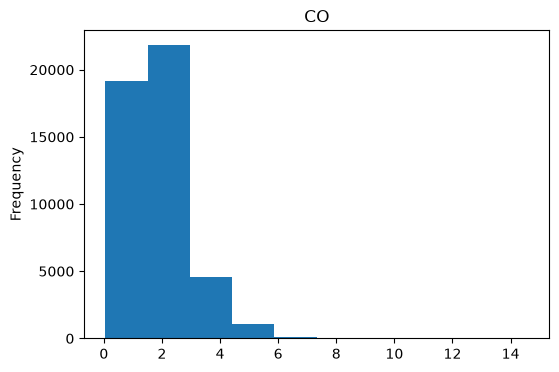

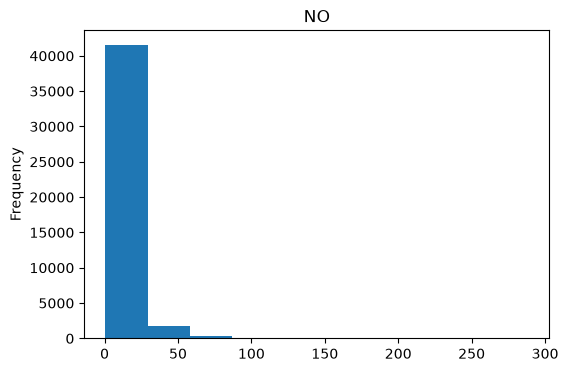

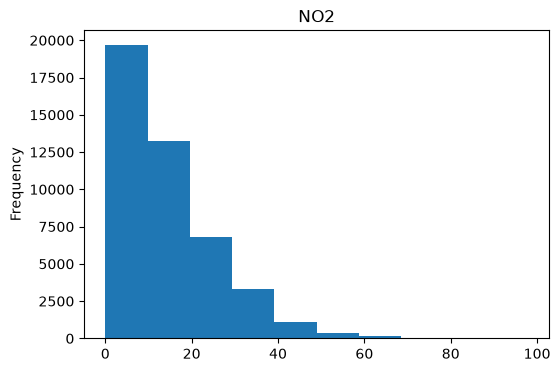

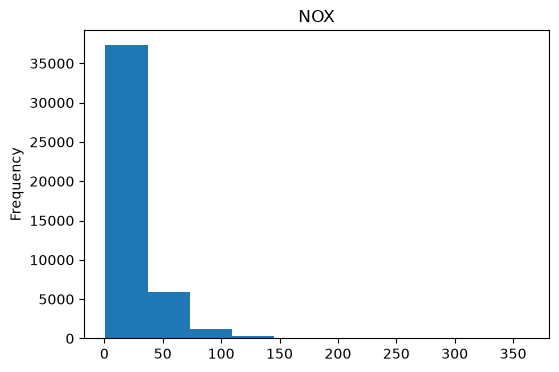

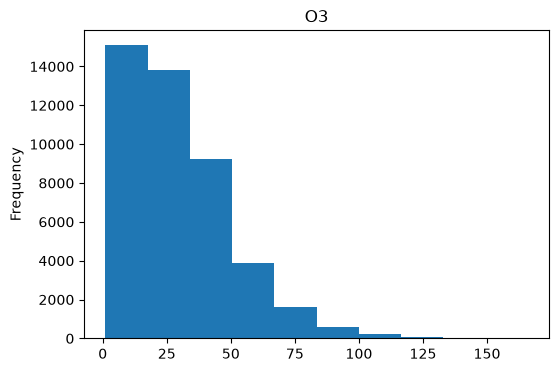

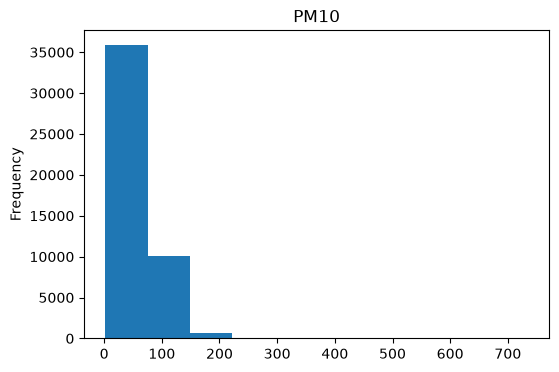

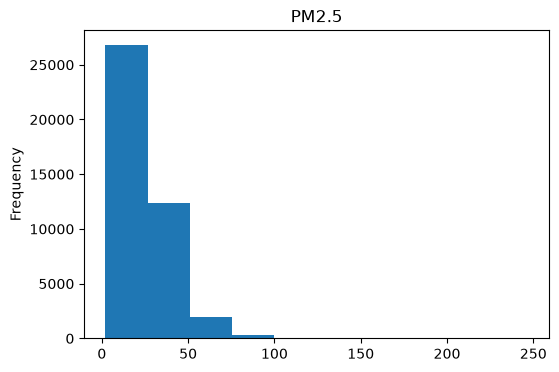

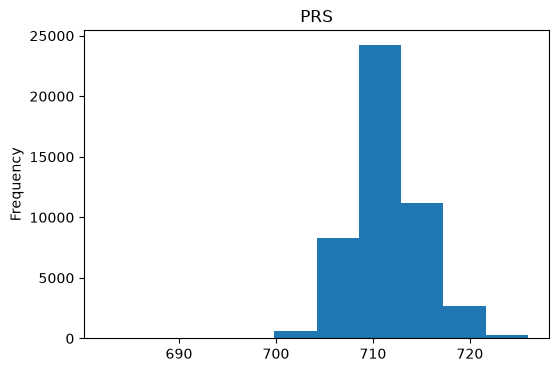

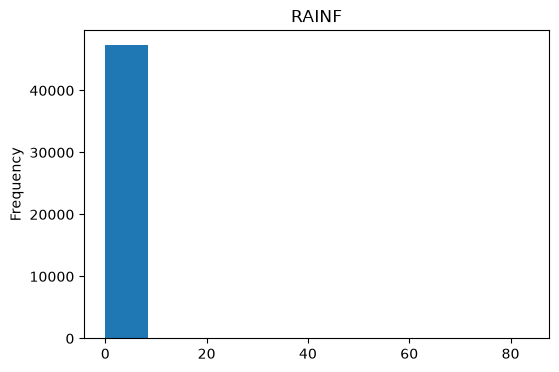

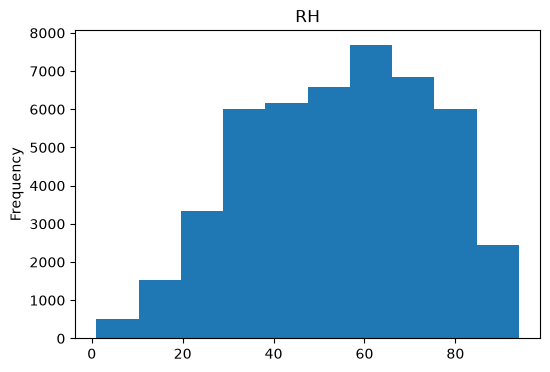

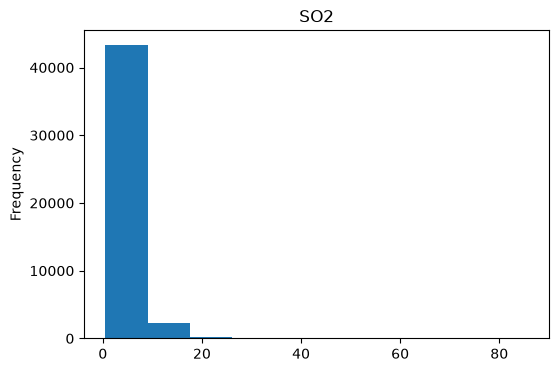

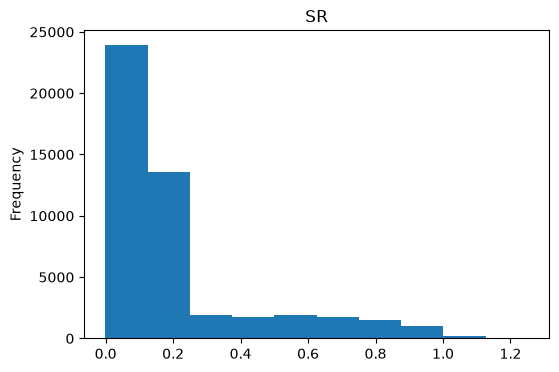

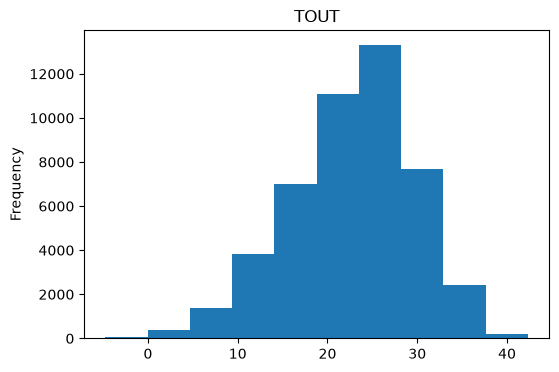

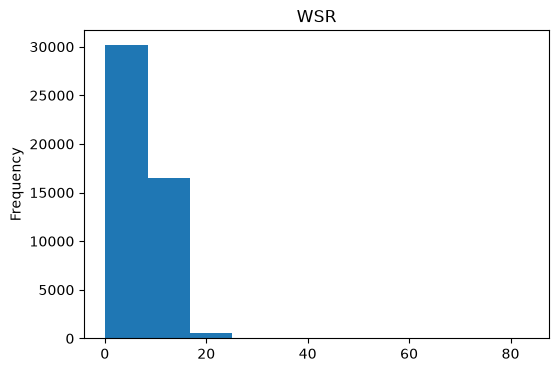

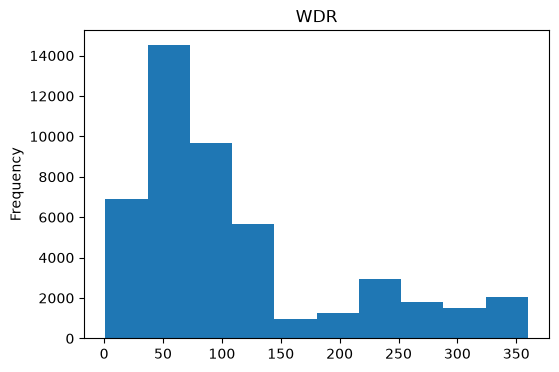

In [53]:
columnas_num = list(ejemplo.columns)
columnas_num = [col for col in columnas_num if col != 'anio' and col != 'date']

for col in columnas_num:
    # forzar a ser numérico, convirtiendo errores a NaN
    ejemplo[col] = pd.to_numeric(ejemplo[col], errors='coerce')
    plt.figure(figsize=(6, 4))
    ejemplo[col].plot(kind='hist', title=col)
    plt.show()

Todo parece correcto.

Ahora quiero verificar que solamente haya valores numéricos en las variables. Se encontró que el problema era la primer columna de la base de 2025, por lo que se eliminó.

In [54]:
ejemplo = pd.read_csv('../data_estaciones/BD_CE.csv')

for col in columnas_num:

    ejemplo[col] = pd.to_numeric(ejemplo[col], errors='raise')

No hay problemas con las variables, todas son numéricas a excepción de la fecha.

In [56]:
data_dir = Path("../data_estaciones")
archivos = sorted(data_dir.glob("*.csv"))

for col in columnas_num:
    descripcion = []
    for archivo in archivos:
        estacion = pd.read_csv(archivo)
        estacion[col] = pd.to_numeric(estacion[col], errors='raise')
        descripcion.append({
            'archivo': archivo.name,
            'min': estacion[col].min(),
            'max': estacion[col].max(),
            'mean': estacion[col].mean(),
            'std': estacion[col].std(),
            'count': estacion[col].count(),
            'nulls': estacion[col].isnull().sum()
        })
    descripcion_df = pd.DataFrame(descripcion)
    print(f"\nDescripción de la variable '{col}':")
    display(descripcion_df)



Descripción de la variable 'CO':


,archivo,min,max,mean,std,count,nulls
0,BD_CE.csv,0.05,14.600,1.873944,0.989521,46741,1449
1,BD_NE.csv,0.05,15.300,1.624696,1.004736,42218,5962
2,BD_NE2.csv,0.00,13.380,1.791726,0.905883,40412,7765
3,BD_NE3.csv,0.05,13.422,0.445064,0.330955,36866,2512
4,BD_NO.csv,0.05,9.790,1.638701,0.675145,34279,13902
5,BD_NO2.csv,0.05,22.380,1.342502,0.843059,46782,1397
6,BD_NO3.csv,0.05,6.000,1.475682,0.827713,19966,2640
7,BD_NTE.csv,0.05,7.460,0.860028,0.479140,36271,11909
8,BD_NTE2.csv,0.00,13.790,1.174378,0.564157,45376,2802
9,BD_SE.csv,0.00,37.000,1.544008,0.849360,43625,4558



Descripción de la variable 'NO':


,archivo,min,max,mean,std,count,nulls
0,BD_CE.csv,0.5,288.4,7.797848,12.170563,43733,4457
1,BD_NE.csv,0.5,273.6,10.200948,18.797697,40592,7588
2,BD_NE2.csv,0.3,500.0,16.460443,21.231279,34947,13230
3,BD_NE3.csv,1.3,313.5,13.792900,12.992409,36382,2996
4,BD_NO.csv,0.5,945.1,9.828221,22.108495,38120,10061
5,BD_NO2.csv,0.5,500.0,17.499675,34.056517,42808,5371
6,BD_NO3.csv,0.5,500.0,13.110861,25.779152,15615,6991
7,BD_NTE.csv,0.5,304.1,12.779516,25.029206,35267,12913
8,BD_NTE2.csv,0.5,500.0,21.543902,28.387420,39381,8797
9,BD_SE.csv,0.5,210.0,9.743873,14.919984,35660,12523



Descripción de la variable 'NO2':


...

,archivo,min,max,mean,std,count,nulls
0,BD_CE.csv,-4.75,42.34,22.743559,6.900594,47306,884
1,BD_NE.csv,-9999.00,785.00,22.479576,52.207881,37833,10347
2,BD_NE2.csv,-5.67,112.39,23.770159,7.349830,46938,1239
3,BD_NE3.csv,-4.10,44.10,23.237125,7.773891,37610,1768
4,BD_NO.csv,-7.08,44.07,23.567283,7.056756,41948,6233
5,BD_NO2.csv,-6.30,43.65,22.533443,7.295930,46933,1246
6,BD_NO3.csv,-3.40,43.95,22.986067,7.568607,22341,265
7,BD_NTE.csv,-67.49,47.58,22.843113,10.982252,37830,10350
8,BD_NTE2.csv,-5.38,44.25,23.703597,7.138147,47626,552
9,BD_SE.csv,-9.62,43.62,23.293787,7.260596,44523,3660



Descripción de la variable 'WSR':


,archivo,min,max,mean,std,count,nulls
0,BD_CE.csv,0.1,83.45,7.327385,3.854623,47231,959
1,BD_NE.csv,0.1,127.50,8.698845,4.637401,41387,6793
2,BD_NE2.csv,0.1,168.40,9.038248,7.025812,41409,6768
3,BD_NE3.csv,0.5,34.40,8.105802,5.459845,36831,2547
4,BD_NO.csv,0.1,58.50,8.495131,5.558046,45226,2955
5,BD_NO2.csv,0.1,62.10,9.759525,5.385213,46153,2026
6,BD_NO3.csv,0.1,215.90,11.365560,12.796435,20415,2191
7,BD_NTE.csv,0.1,35.20,7.684231,4.436737,38702,9478
8,BD_NTE2.csv,0.1,29.70,7.801196,3.331957,47659,519
9,BD_SE.csv,0.3,64.00,10.499863,5.598527,47331,852



Descripción de la variable 'WDR':


,archivo,min,max,mean,std,count,nulls
0,BD_CE.csv,1.0,360.0,111.096062,89.986570,47281,909
1,BD_NE.csv,1.0,360.0,136.951032,80.887995,44253,3927
2,BD_NE2.csv,1.0,360.0,193.107335,92.823283,43602,4575
3,BD_NE3.csv,1.0,360.0,154.719697,92.663346,37807,1571
4,BD_NO.csv,1.0,360.0,148.374119,102.519109,42711,5470
5,BD_NO2.csv,1.0,360.0,128.868072,86.935347,44491,3688
6,BD_NO3.csv,1.0,360.0,95.064312,90.542553,22142,464
7,BD_NTE.csv,1.0,360.0,98.999332,90.538650,37428,10752
8,BD_NTE2.csv,1.0,360.0,103.336632,85.881022,47589,589
9,BD_SE.csv,1.0,360.0,143.098208,90.354638,37604,10579
